In [87]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.ndimage import binary_dilation

# Domain
l_x = 6e-3
l_y = 6e-3
v_l = +5000
v_r = 0
n_x = 256
n_y = 256

dx = l_x / n_x
dy = l_y / n_y

x_i = np.linspace(0, l_x, n_x)
y_j = np.linspace(0, l_y, n_y)  

a  = 2.0e-3       
b  = 0.75e-3       
yc = l_y / 2      

# Storage
phi        = np.zeros((n_y, n_x))
is_cathode = np.zeros((n_y, n_x), dtype=bool)
is_anode   = np.zeros((n_y, n_x), dtype=bool)


In [88]:
# Flag electrode nodes
for i in range(n_x):
    for j in range(n_y):
        xi = x_i[i]
        yj = y_j[j]

        if (xi/a)**2 + ((yj - yc)/b)**2 <= 1.0:
            is_cathode[j, i] = True
            phi[j, i]        = v_l

        elif ((l_x - xi)/a)**2 + ((yj - yc)/b)**2 <= 1.0:
            is_anode[j, i] = True
            phi[j, i]      = v_r

is_dirichlet = is_cathode | is_anode

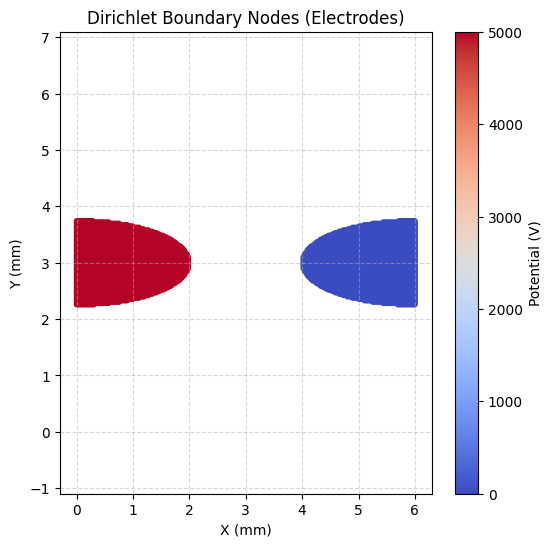

In [89]:
y_indices, x_indices = np.where(is_dirichlet)

x_scatter = x_i[x_indices]
y_scatter = y_j[y_indices]

plt.figure(figsize=(6, 6))
plt.scatter(x_scatter * 1e3, y_scatter * 1e3, c=phi[is_dirichlet], cmap='coolwarm', s=10)

plt.colorbar(label='Potential (V)')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title('Dirichlet Boundary Nodes (Electrodes)')
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [90]:
max_iter=150000
for iteration in range(max_iter):
    phi_old = phi.copy()
    
    phi[1:-1, 1:-1] = (
        (phi[1:-1, 2:] + phi[1:-1, :-2]) / dx**2 +
        (phi[2:, 1:-1] + phi[:-2, 1:-1]) / dy**2
    ) / (2/dx**2 + 2/dy**2)
    
    phi[is_cathode] = v_l
    phi[is_anode]   = v_r
    
    if np.max(np.abs(phi - phi_old)) < 1e-3:
        print(f"Converged at iteration {iteration}")
        break


Converged at iteration 33388


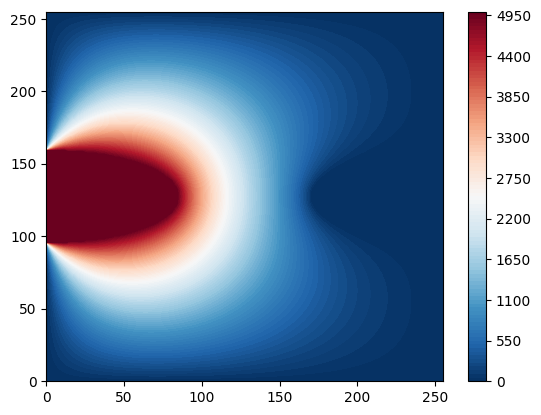

In [91]:
plt.contourf(phi, levels=100, cmap='RdBu_r')
plt.colorbar()


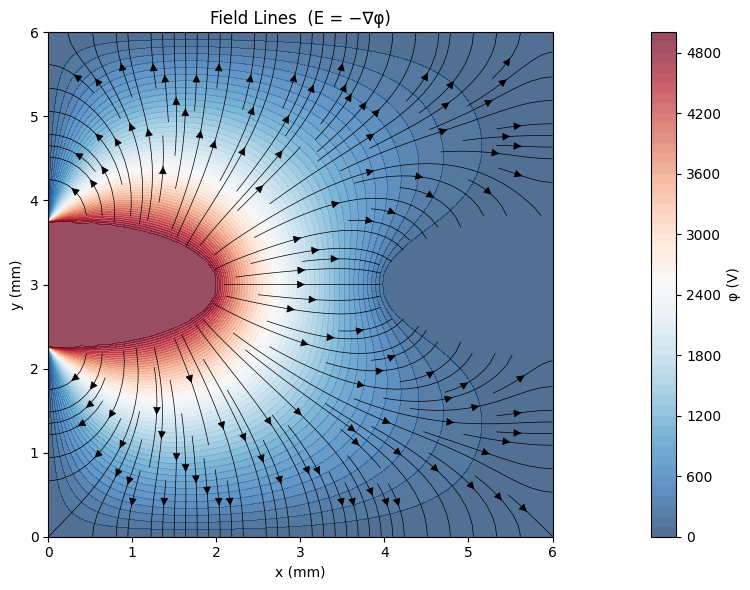

In [92]:
Ex = np.zeros((n_y, n_x))
Ey = np.zeros((n_y, n_x))

Ex[1:-1, 1:-1] = -(phi[1:-1, 2:] - phi[1:-1, :-2]) / (2 * dx)
Ey[1:-1, 1:-1] = -(phi[2:, 1:-1] - phi[:-2, 1:-1]) / (2 * dy)
E_mag = np.sqrt(Ex**2 + Ey**2)

electrode_dilated = binary_dilation(is_dirichlet, iterations=2)
E_mag_plot = np.where(electrode_dilated, np.nan, E_mag)
Ex_plot    = np.where(electrode_dilated, 0.0, Ex)
Ey_plot    = np.where(electrode_dilated, 0.0, Ey)

X_mm, Y_mm = np.meshgrid(x_i * 1e3, y_j * 1e3)

fig, axes = plt.subplots(1, 1, figsize=(20, 6))


cf = axes.contourf(X_mm, Y_mm, phi, levels=60, cmap='RdBu_r', alpha=0.7)
plt.colorbar(cf, ax=axes, label='φ (V)')
axes.streamplot(x_i * 1e3, y_j * 1e3, Ex_plot, Ey_plot,
                   color='black', linewidth=0.5,density=1.5, arrowsize=1.2)

axes.set_title('Field Lines  (E = −∇φ)')
axes.set_xlabel('x (mm)');  axes.set_ylabel('y (mm)')
axes.set_aspect('equal')

plt.tight_layout()
plt.show()

In [ ]:
q = +1.6e-19    # electron charge (negative — moves OPPOSITE to E field)
m =  9.1e-31    # electron mass

def interpolate_E(x, y, Ex, Ey, dx, dy, n_x, n_y):
    i = int(x / dx)
    j = int(y / dy)

    i = np.clip(i, 0, n_x - 2)
    j = np.clip(j, 0, n_y - 2)

    sx = (x - i * dx) / dx    
    sy = (y - j * dy) / dy    

    Ex_p = ((1-sx)*(1-sy) * Ex[j,   i  ]
          +    sx *(1-sy) * Ex[j,   i+1]
          + (1-sx)*   sy  * Ex[j+1, i  ]
          +    sx *   sy  * Ex[j+1, i+1])

    Ey_p = ((1-sx)*(1-sy) * Ey[j,   i  ]
          +    sx *(1-sy) * Ey[j,   i+1]
          + (1-sx)*   sy  * Ey[j+1, i  ]
          +    sx *   sy  * Ey[j+1, i+1])

    return Ex_p, Ey_p

def boris_push(vx, vy, Ex_p, Ey_p, q, m, dt):
    vx += (q / m) * Ex_p * dt
    vy += (q / m) * Ey_p * dt
    return vx, vy

N  = 15

y  = np.linspace(0 , l_y , N)
x  = np.linspace(0 , l_y , N)
vx = np.zeros(N)
vy = np.zeros(N)

dt      = 5e-13
n_steps = 3000

# store full trajectories for plotting
traj_x = np.zeros((n_steps + 1, N))
traj_y = np.zeros((n_steps + 1, N))
traj_x[0] = x.copy()
traj_y[0] = y.copy()

active = np.ones(N, dtype=bool)    # False once electron hits wall or electrode

for step in range(n_steps):
    for k in range(N):
        if not active[k]:
            continue

        Ex_k, Ey_k = interpolate_E(x[k], y[k], Ex, Ey, dx, dy, n_x, n_y)
        vx[k], vy[k] = boris_push(vx[k], vy[k], Ex_k, Ey_k, q, m, dt)

        x[k] += vx[k] * dt
        y[k] += vy[k] * dt

        i_k = int(np.clip(x[k] / dx, 0, n_x - 1))
        j_k = int(np.clip(y[k] / dy, 0, n_y - 1))

        if (x[k] <= 0 or x[k] >= l_x or
            y[k] <= 0 or y[k] >= l_y or
            is_dirichlet[j_k, i_k]):
            active[k] = False

    traj_x[step + 1] = x.copy()
    traj_y[step + 1] = y.copy()

print(f"Electrons still active at end: {active.sum()} / {N}")



Electrons still active at end: 0 / 15


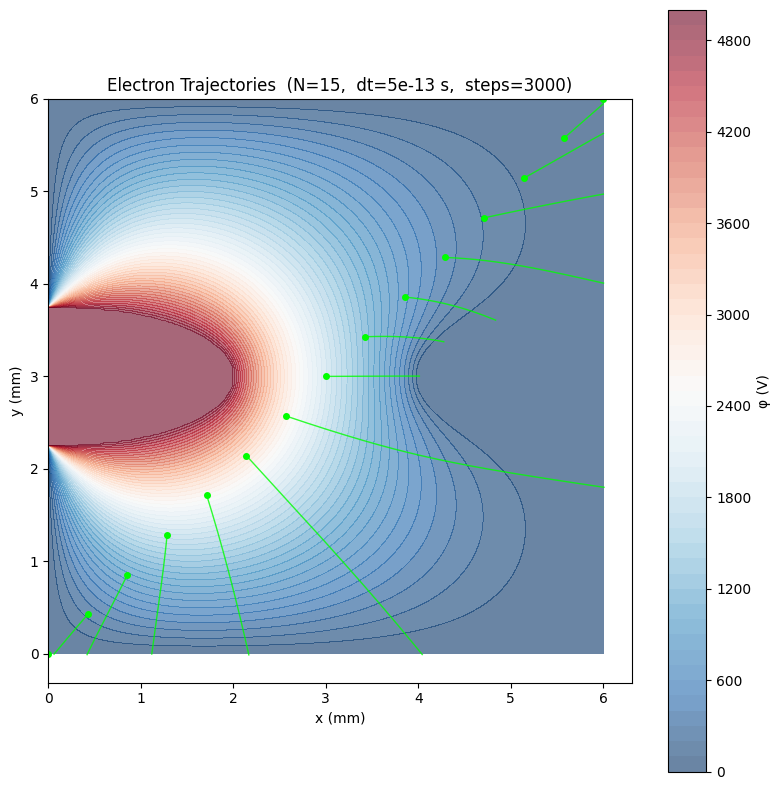

In [96]:
X_mm, Y_mm = np.meshgrid(x_i * 1e3, y_j * 1e3)

fig, ax = plt.subplots(figsize=(8, 8))

# background — potential
cf = ax.contourf(X_mm, Y_mm, phi, levels=60, cmap='RdBu_r', alpha=0.6)
plt.colorbar(cf, ax=ax, label='φ (V)')

# field lines

# trajectories
for k in range(N):
    # find last active step
    if active[k]:
        end = n_steps
    else:
        end = np.argmin(active)   # approximate

    ax.plot(traj_x[:, k] * 1e3, traj_y[:, k] * 1e3,
            color='lime', linewidth=1.0, alpha=0.8)
    ax.plot(traj_x[0, k] * 1e3, traj_y[0, k] * 1e3,
            'o', color='lime', markersize=4)   # start

ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title(f'Electron Trajectories  (N={N},  dt={dt:.0e} s,  steps={n_steps})')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()
